In [1]:
## Environment setup

import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing, Holt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13, "axes.labelsize": 11})
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
print("✅ Libraries loaded")


✅ Libraries loaded


In [3]:
## Load preprocessed datasets

BASE = Path("/Users/jemwagas/ProjectForecastingModel/")
df        = pd.read_csv(BASE / "features_engineered.csv", parse_dates=["Transaction_Date"])
customers = pd.read_csv(BASE / "customers_clean.csv")
products  = pd.read_csv(BASE / "products_clean.csv")

print(f"features_engineered : {df.shape}")
print(f"Date range          : {df.Transaction_Date.min().date()} → {df.Transaction_Date.max().date()}")
df.head(3)


features_engineered : (10000, 55)
Date range          : 2020-01-11 → 2024-12-10


,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost,Year,Month,Quarter,...,Recency_Scaled,Frequency_Scaled,Monetary_Scaled,AvgSpend_Scaled,TotalQty_Scaled,UniqueProds_Scaled,Company_Profit_Scaled,SpendVsProfit_Scaled,AvgSpendPerProduct_Scaled,FreqPerMonth_Scaled
0,1,88,6,10,2024-03-26,194379.147964,1075200.0,2024,3,1,...,-0.203375,-0.366255,-0.350926,1.027470,-0.344801,0.583157,-0.013276,-0.414163,-0.356025,-0.210013
1,2,29,19,16,2024-07-09,97930.993380,1428000.0,2024,7,3,...,-0.636529,-0.390788,-0.373607,1.262999,-0.378037,-1.129996,-0.602692,0.121309,-0.365782,-0.364574
2,10000,28,18,6,2024-04-13,126095.547778,940800.0,2024,4,2,...,-0.010863,-0.375455,-0.353552,1.517450,-0.347113,-1.129996,NaN,NaN,-0.344689,-0.274441


In [5]:
## Implement and verify features

# ── Monthly aggregate (base for all time-series models)
monthly = (
    df.groupby(["Year", "Month"])
      .agg(Monthly_Sales=("Total_Cost", "sum"),
           Tx_Count=("Transaction_ID", "count"),
           Avg_Order=("Total_Cost", "mean"),
           Total_Qty=("Quantity", "sum"),
           Unique_Customers=("Company_ID", "nunique"),
           Unique_Products=("Product_ID", "nunique"))
      .reset_index().sort_values(["Year", "Month"])
)
monthly["ds"] = pd.to_datetime(monthly[["Year","Month"]].assign(day=1))
monthly = monthly.set_index("ds")
monthly = monthly[monthly.index < "2024-11-01"]   # exclude partial months

# ── Lag features
for lag, name in [(1,"Lag_1m"),(3,"Lag_3m"),(6,"Lag_6m"),(12,"Lag_12m")]:
    monthly[f"Sales_{name}"] = monthly["Monthly_Sales"].shift(lag)

# ── Rolling statistics
monthly["Rolling_Mean_3m"] = monthly["Monthly_Sales"].shift(1).rolling(3).mean()
monthly["Rolling_Std_3m"]  = monthly["Monthly_Sales"].shift(1).rolling(3).std()
monthly["Rolling_Mean_6m"] = monthly["Monthly_Sales"].shift(1).rolling(6).mean()

# ── Growth rates
monthly["MoM_Growth"] = monthly["Monthly_Sales"].pct_change()
monthly["YoY_Growth"] = monthly["Monthly_Sales"].pct_change(12)

# ── Seasonal index
month_avg = monthly.groupby(monthly.index.month)["Monthly_Sales"].mean()
grand_avg  = monthly["Monthly_Sales"].mean()
monthly["Seasonal_Index"] = monthly.index.map(lambda d: month_avg[d.month] / grand_avg)

# ── Transaction-level features
df["Revenue_Per_Unit"] = df["Total_Cost"] / df["Quantity"].replace(0, np.nan)
df["Spend_Velocity"]   = df["Monetary"]   / df["Recency"].replace(0, np.nan)

rpu = df.groupby(["Year","Month"])["Revenue_Per_Unit"].mean().reset_index()
rpu["ds"] = pd.to_datetime(rpu[["Year","Month"]].assign(day=1))
monthly["Avg_Revenue_Per_Unit"] = rpu.set_index("ds")["Revenue_Per_Unit"]

# ── RFM tiers
rfm = df[["Company_ID","Recency","Frequency","Monetary"]].drop_duplicates("Company_ID").copy()
for col, label in [("Recency","R_Score"),("Frequency","F_Score"),("Monetary","M_Score")]:
    rfm[label] = pd.qcut(rfm[col], 4,
                          labels=[4,3,2,1] if col=="Recency" else [1,2,3,4],
                          duplicates="drop").astype(int)
rfm["RFM_Score"]   = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]
rfm["RFM_Segment"] = pd.cut(rfm["RFM_Score"], bins=[2,5,8,12],
                              labels=["At-Risk","Potential","Champions"])
df = df.merge(rfm[["Company_ID","RFM_Score","RFM_Segment"]], on="Company_ID", how="left")
df["Price_Qty_Ratio"] = df["Product_Price"] / df["Quantity"].replace(0, np.nan)

# ── Cumulative YTD
monthly["Cumulative_YTD"] = monthly.groupby(monthly.index.year)["Monthly_Sales"].cumsum()

# ── Weekend ratio
wknd = df.groupby(["Year","Month"]).apply(
    lambda g: g.loc[g["IsWeekend"]==1,"Total_Cost"].sum() / g["Total_Cost"].sum()
              if g["Total_Cost"].sum() > 0 else 0).reset_index()
wknd.columns = ["Year","Month","Weekend_Ratio"]
wknd["ds"] = pd.to_datetime(wknd[["Year","Month"]].assign(day=1))
monthly["Weekend_Ratio"] = wknd.set_index("ds")["Weekend_Ratio"]
monthly.reset_index(inplace=True)

print(f"✅ Monthly features shape: {monthly.shape}")
print(f"Seasonal Index mean (should ≈ 1.0): {monthly['Seasonal_Index'].mean():.4f}")
print(f"RFM Segments:\n{rfm['RFM_Segment'].value_counts().to_string()}")
monthly[["ds","Monthly_Sales","Sales_Lag_1m","Rolling_Mean_3m","Seasonal_Index"]].tail(6)


✅ Monthly features shape: (58, 22)
Seasonal Index mean (should ≈ 1.0): 1.0000
RFM Segments:
RFM_Segment
Potential    38
Champions    37
At-Risk      25


,ds,Monthly_Sales,Sales_Lag_1m,Rolling_Mean_3m,Seasonal_Index
52,2024-05-01,2.970240e+08,2.554501e+08,2.686044e+08,1.000418
53,2024-06-01,2.779025e+08,2.970240e+08,2.877438e+08,0.977603
54,2024-07-01,3.315090e+08,2.779025e+08,2.767922e+08,1.071590
55,2024-08-01,2.760527e+08,3.315090e+08,3.021452e+08,0.968111
56,2024-09-01,2.759870e+08,2.760527e+08,2.951547e+08,0.938511
57,2024-10-01,2.359139e+08,2.759870e+08,2.945162e+08,0.979740


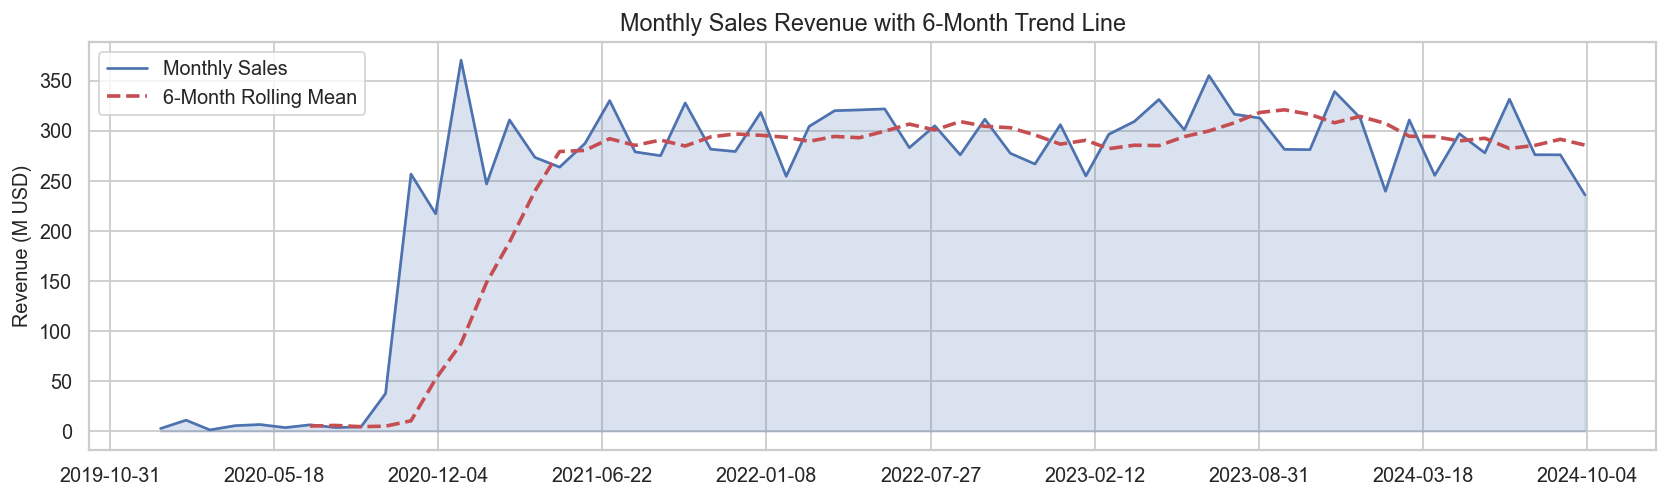

In [7]:
# Fig 1: Monthly Sales Trend + Rolling Mean
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(monthly["ds"], monthly["Monthly_Sales"]/1e6, alpha=0.2, color="#4C72B0")
ax.plot(monthly["ds"], monthly["Monthly_Sales"]/1e6, color="#4C72B0", lw=1.5, label="Monthly Sales")
ax.plot(monthly["ds"], monthly["Rolling_Mean_6m"]/1e6, color="#C44E52", lw=2, ls="--", label="6-Month Rolling Mean")
ax.set_title("Monthly Sales Revenue with 6-Month Trend Line"); ax.set_ylabel("Revenue (M USD)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(10)); ax.legend()
plt.tight_layout(); plt.savefig(OUT/"fig1_monthly_sales_trend.png", dpi=130); plt.show()


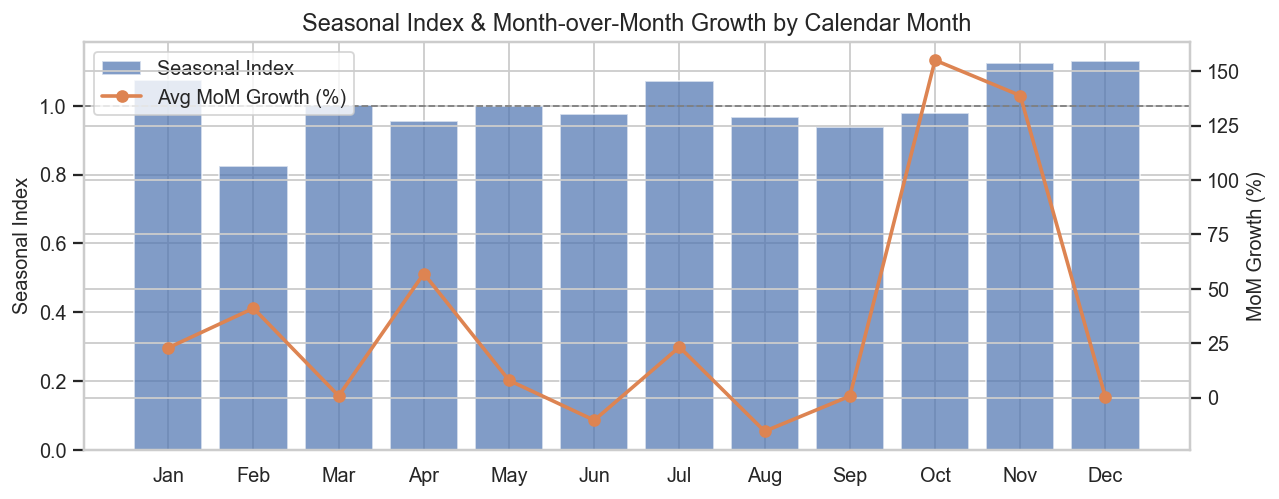

In [9]:
# Fig 2: Seasonal Index + MoM Growth
fig, ax1 = plt.subplots(figsize=(10, 4))
month_si = monthly.groupby(monthly["ds"].dt.month)["Seasonal_Index"].mean()
ax1.bar(month_si.index, month_si.values, color="#4C72B0", alpha=0.7, label="Seasonal Index")
ax1.axhline(1.0, color="grey", ls="--", lw=1); ax1.set_ylabel("Seasonal Index")
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax2 = ax1.twinx()
mom_avg = monthly.groupby(monthly["ds"].dt.month)["MoM_Growth"].mean() * 100
ax2.plot(mom_avg.index, mom_avg.values, color="#DD8452", marker="o", lw=2, label="Avg MoM Growth (%)")
ax2.set_ylabel("MoM Growth (%)")
ax1.set_title("Seasonal Index & Month-over-Month Growth by Calendar Month")
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper left")
plt.tight_layout(); plt.savefig(OUT/"fig2_seasonal_index.png", dpi=130); plt.show()


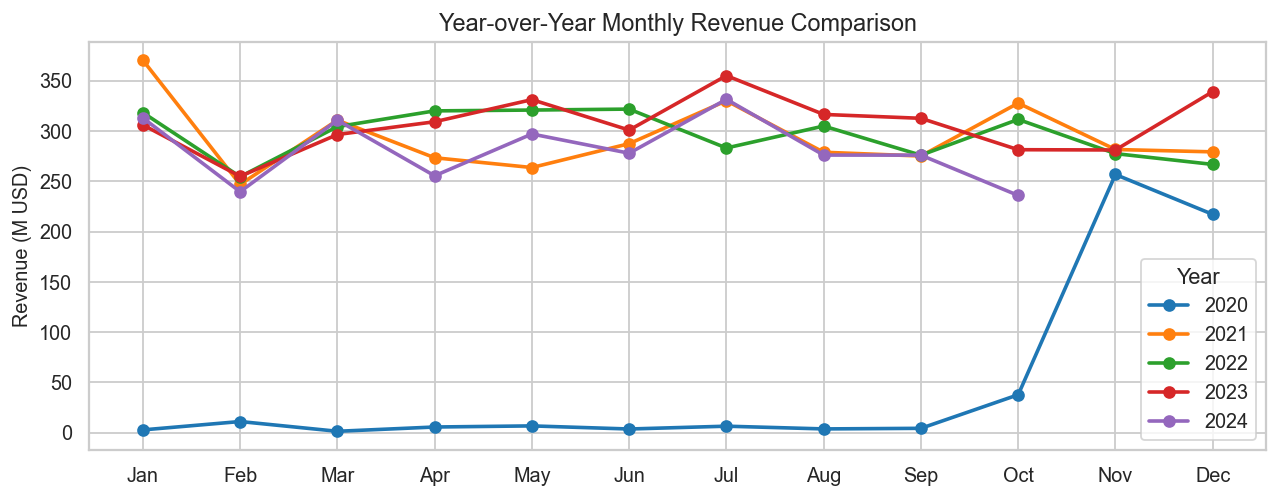

In [11]:
# Fig 3: Year-over-Year comparison
fig, ax = plt.subplots(figsize=(10, 4))
palette_yoy = sns.color_palette("tab10", n_colors=5)
for i, yr in enumerate(sorted(monthly["ds"].dt.year.unique())):
    sub = monthly[monthly["ds"].dt.year == yr]
    ax.plot(sub["ds"].dt.month, sub["Monthly_Sales"]/1e6,
            marker="o", lw=2, color=palette_yoy[i], label=str(yr))
ax.set_xticks(range(1,13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Year-over-Year Monthly Revenue Comparison"); ax.set_ylabel("Revenue (M USD)")
ax.legend(title="Year"); plt.tight_layout()
plt.savefig(OUT/"fig3_yoy_comparison.png", dpi=130); plt.show()


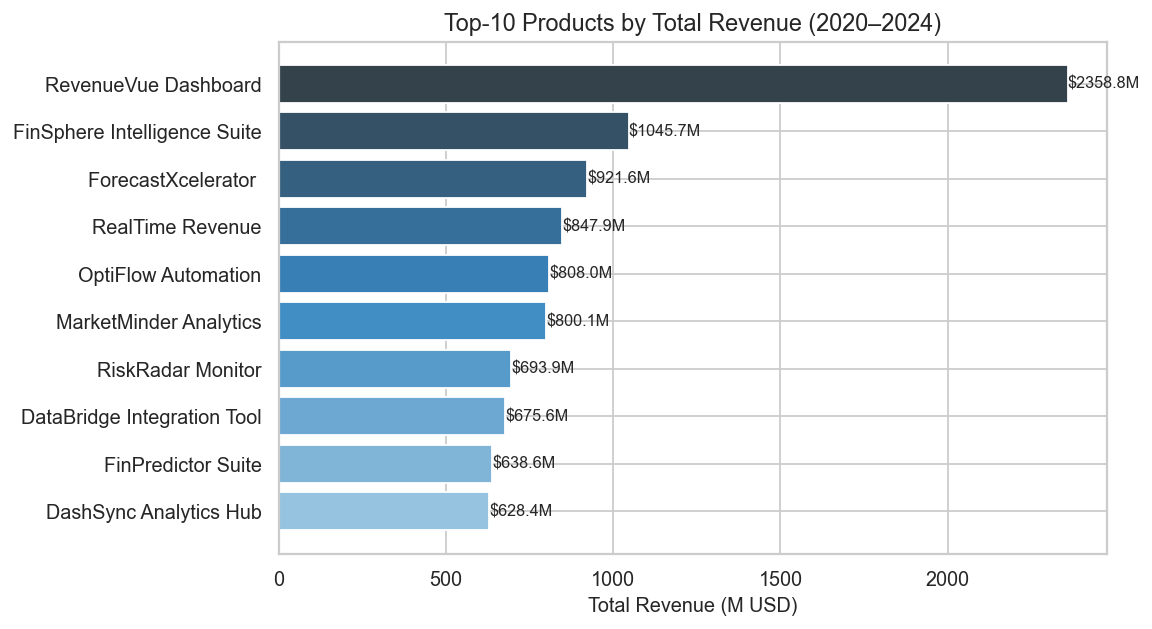

In [13]:
# Fig 4: Top-10 products by revenue
prod_rev = df.groupby("Product_Name")["Total_Cost"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(prod_rev.index[::-1], prod_rev.values[::-1]/1e6,
               color=sns.color_palette("Blues_d", 10))
ax.set_xlabel("Total Revenue (M USD)"); ax.set_title("Top-10 Products by Total Revenue (2020–2024)")
for bar, val in zip(bars, prod_rev.values[::-1]/1e6):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f"${val:.1f}M", va="center", fontsize=9)
plt.tight_layout(); plt.savefig(OUT/"fig4_top_products.png", dpi=130); plt.show()


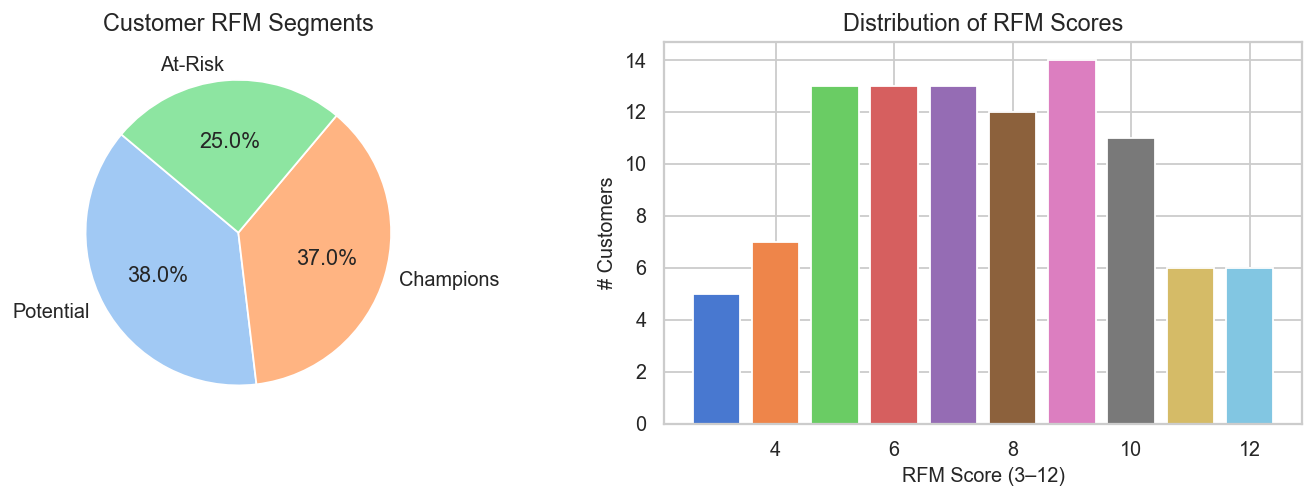

In [15]:
# Fig 5: RFM segments
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rfm_counts = rfm["RFM_Segment"].value_counts()
axes[0].pie(rfm_counts, labels=rfm_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("pastel"), startangle=140)
axes[0].set_title("Customer RFM Segments")
rfm_sc = rfm["RFM_Score"].value_counts().sort_index()
axes[1].bar(rfm_sc.index, rfm_sc.values, color=sns.color_palette("muted"))
axes[1].set_xlabel("RFM Score (3–12)"); axes[1].set_ylabel("# Customers")
axes[1].set_title("Distribution of RFM Scores")
plt.tight_layout(); plt.savefig(OUT/"fig5_rfm_segments.png", dpi=130); plt.show()


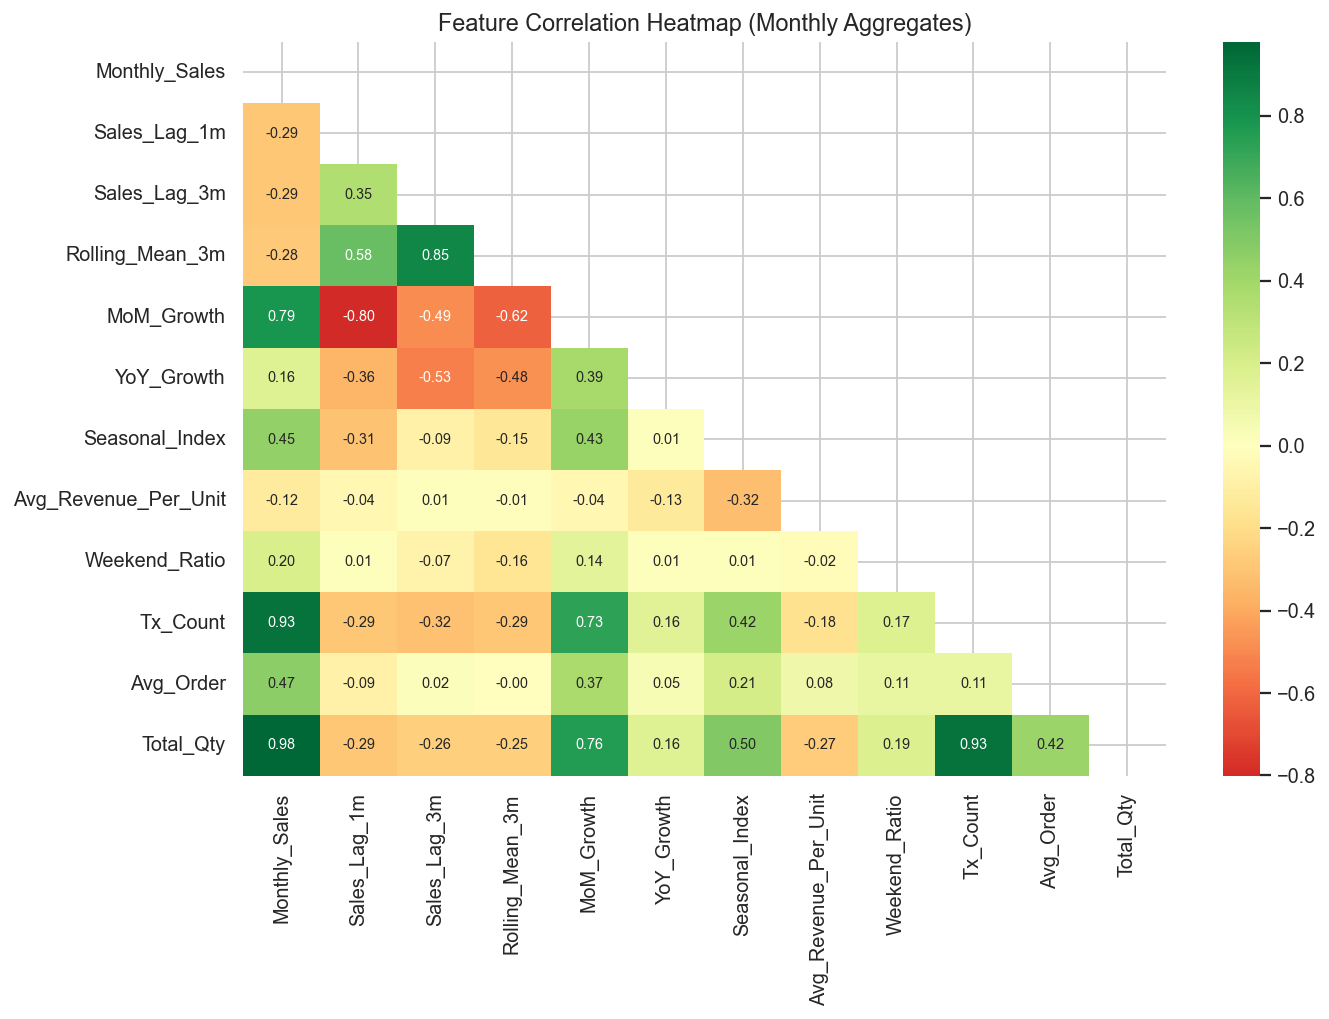

In [17]:
# Fig 6: Correlation heatmap
corr_cols = ["Monthly_Sales","Sales_Lag_1m","Sales_Lag_3m","Rolling_Mean_3m",
             "MoM_Growth","YoY_Growth","Seasonal_Index","Avg_Revenue_Per_Unit",
             "Weekend_Ratio","Tx_Count","Avg_Order","Total_Qty"]
corr_df = monthly[corr_cols].dropna()
fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, ax=ax, annot_kws={"size":8})
ax.set_title("Feature Correlation Heatmap (Monthly Aggregates)")
plt.tight_layout(); plt.savefig(OUT/"fig6_correlation_heatmap.png", dpi=130); plt.show()


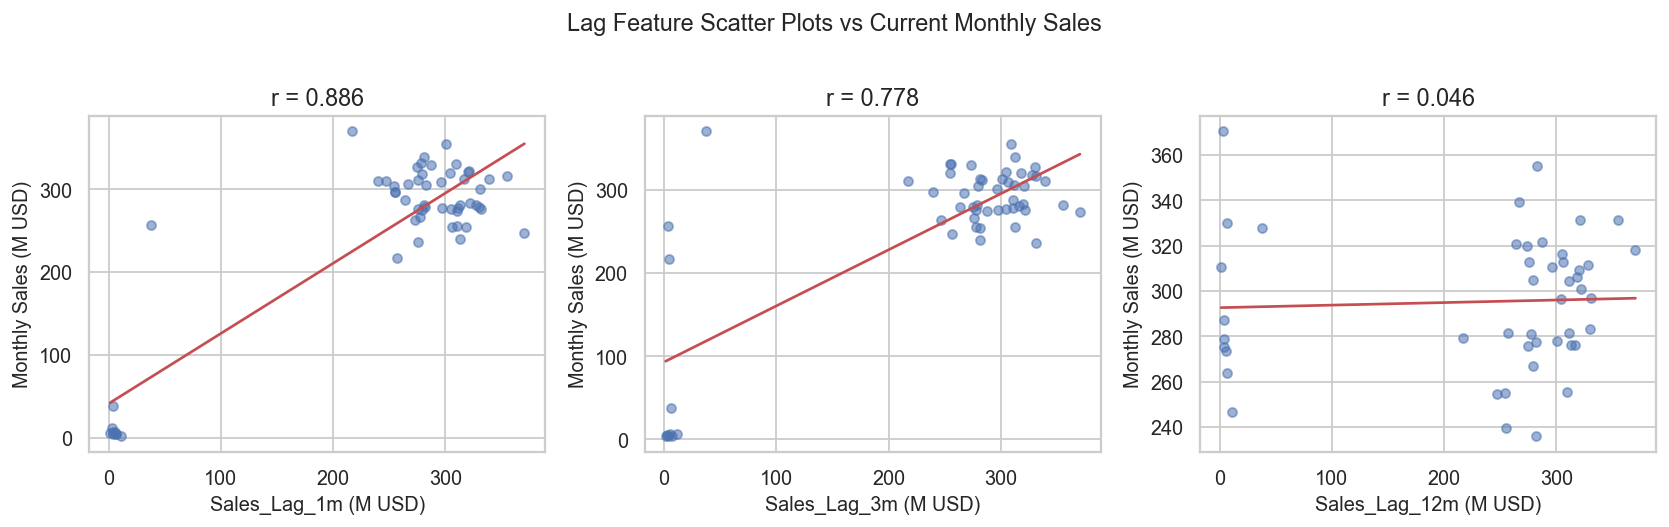

In [19]:
# Fig 7: Lag scatter plots
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, lag in zip(axes, ["Sales_Lag_1m","Sales_Lag_3m","Sales_Lag_12m"]):
    sub = monthly[["Monthly_Sales", lag]].dropna()
    ax.scatter(sub[lag]/1e6, sub["Monthly_Sales"]/1e6, alpha=0.55, color="#4C72B0", s=25)
    m, b = np.polyfit(sub[lag]/1e6, sub["Monthly_Sales"]/1e6, 1)
    x_ = np.linspace(sub[lag].min(), sub[lag].max(), 50)/1e6
    ax.plot(x_, m*x_+b, color="#C44E52", lw=1.5)
    r = sub.corr().iloc[0,1]
    ax.set_xlabel(f"{lag} (M USD)"); ax.set_ylabel("Monthly Sales (M USD)")
    ax.set_title(f"r = {r:.3f}")
fig.suptitle("Lag Feature Scatter Plots vs Current Monthly Sales", fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig(OUT/"fig7_lag_scatter.png", dpi=130, bbox_inches="tight"); plt.show()


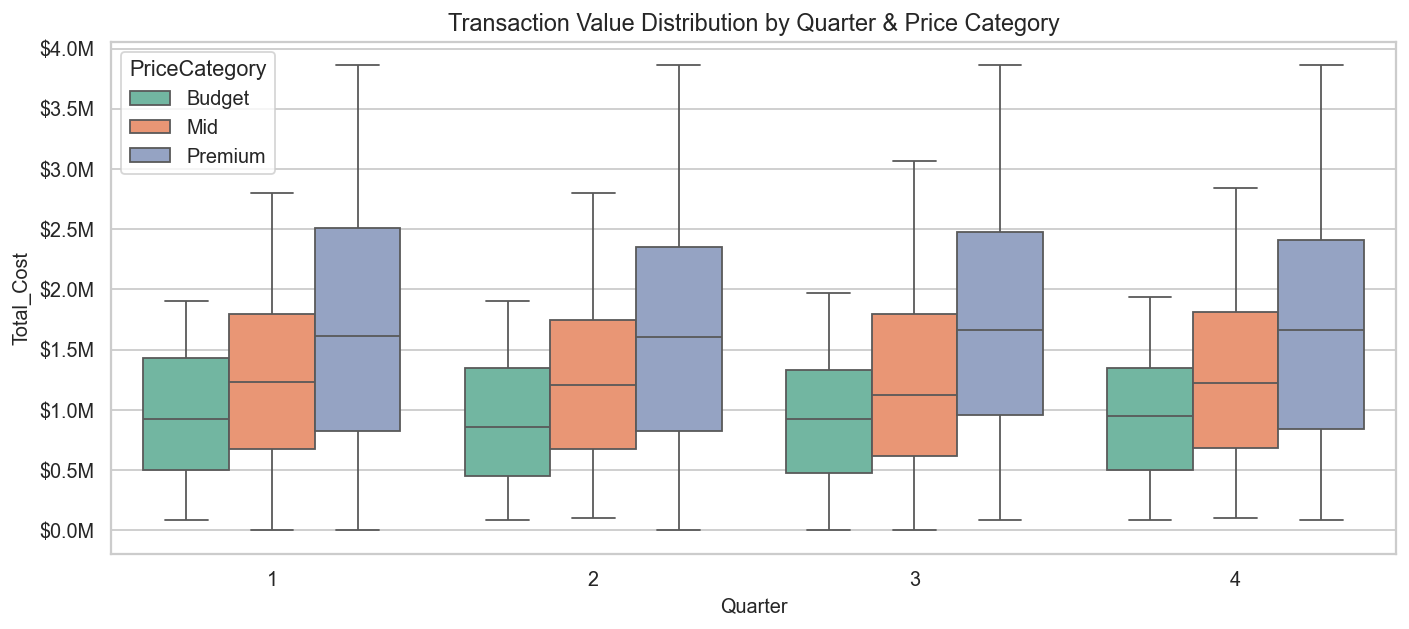

In [21]:
# Fig 8: Quarterly boxplots by price category
fig, ax = plt.subplots(figsize=(11, 5))
present = [c for c in ["Budget","Mid","Premium"] if c in df["PriceCategory"].unique()]
sns.boxplot(data=df, x="Quarter", y="Total_Cost", hue="PriceCategory",
            hue_order=present, palette="Set2", ax=ax, fliersize=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
ax.set_title("Transaction Value Distribution by Quarter & Price Category")
plt.tight_layout(); plt.savefig(OUT/"fig8_quarterly_boxplot.png", dpi=130); plt.show()


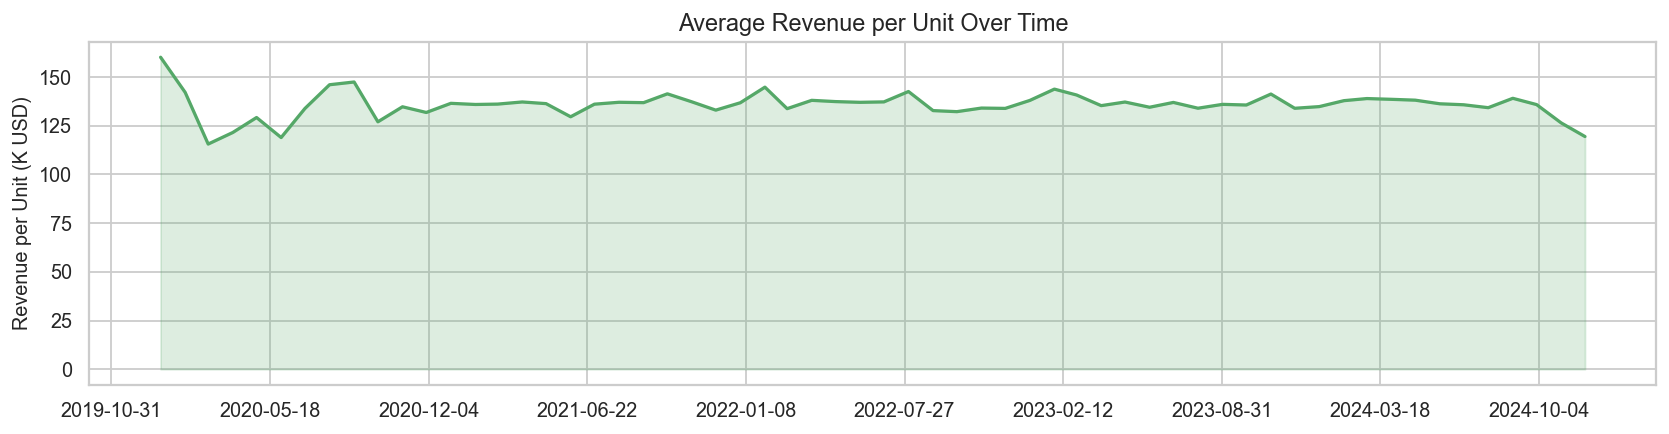

In [23]:
# Fig 9: Revenue per unit trend
rpu_trend = df.groupby(["Year","Month"])["Revenue_Per_Unit"].mean().reset_index()
rpu_trend["ds"] = pd.to_datetime(rpu_trend[["Year","Month"]].assign(day=1))
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(rpu_trend["ds"], rpu_trend["Revenue_Per_Unit"]/1e3, color="#55A868", lw=1.8)
ax.fill_between(rpu_trend["ds"], rpu_trend["Revenue_Per_Unit"]/1e3, alpha=0.2, color="#55A868")
ax.set_title("Average Revenue per Unit Over Time"); ax.set_ylabel("Revenue per Unit (K USD)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(10))
plt.tight_layout(); plt.savefig(OUT/"fig9_revenue_per_unit.png", dpi=130); plt.show()


In [25]:
## Sales Forecasting Models

ts    = monthly[["ds","Monthly_Sales"]].dropna().sort_values("ds")
train = ts.iloc[:-4]
test  = ts.iloc[-4:]
y_train = train["Monthly_Sales"].values
y_test  = test["Monthly_Sales"].values
future_dates = pd.date_range("2025-01-01", periods=3, freq="MS")
n_test = len(test)

print(f"Train: {len(train)} months  ({train.ds.iloc[0].date()} – {train.ds.iloc[-1].date()})")
print(f"Test : {n_test} months   ({test.ds.iloc[0].date()} – {test.ds.iloc[-1].date()})")
print(f"Forecast target: {list(future_dates.strftime('%b %Y'))}")


Train: 54 months  (2020-01-01 – 2024-06-01)
Test : 4 months   (2024-07-01 – 2024-10-01)
Forecast target: ['Jan 2025', 'Feb 2025', 'Mar 2025']


In [27]:
## Moving average

# Moving Average: forecast = mean of the last k months
def moving_average_forecast(train_vals, k, steps):
    history = list(train_vals)
    preds = []
    for _ in range(steps):
        pred = np.mean(history[-k:])
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

ma3_all  = moving_average_forecast(y_train, k=3,  steps=n_test+3)
ma12_all = moving_average_forecast(y_train, k=12, steps=n_test+3)

mae_ma3   = mean_absolute_error(y_test, ma3_all[:n_test])
rmse_ma3  = np.sqrt(mean_squared_error(y_test, ma3_all[:n_test]))
r2_ma3    = r2_score(y_test, ma3_all[:n_test])

mae_ma12  = mean_absolute_error(y_test, ma12_all[:n_test])
rmse_ma12 = np.sqrt(mean_squared_error(y_test, ma12_all[:n_test]))
r2_ma12   = r2_score(y_test, ma12_all[:n_test])

print(f"Moving Average (3-month)  → MAE=${mae_ma3:,.0f}  RMSE=${rmse_ma3:,.0f}  R²={r2_ma3:.3f}")
print(f"Moving Average (12-month) → MAE=${mae_ma12:,.0f}  RMSE=${rmse_ma12:,.0f}  R²={r2_ma12:.3f}")
print("\nInterpretation: MA(3) reacts faster to recent changes; MA(12) smooths out seasonal spikes.")


Moving Average (3-month)  → MAE=$27,570,123  RMSE=$35,421,033  R²=-0.084
Moving Average (12-month) → MAE=$30,095,611  RMSE=$33,802,325  R²=0.013

Interpretation: MA(3) reacts faster to recent changes; MA(12) smooths out seasonal spikes.


In [31]:
## Simple Exponential Smoothing

ses_fit  = SimpleExpSmoothing(y_train, initialization_method="estimated").fit(optimized=True)
ses_all  = ses_fit.forecast(n_test + 3)

mae_ses  = mean_absolute_error(y_test, ses_all[:n_test])
rmse_ses = np.sqrt(mean_squared_error(y_test, ses_all[:n_test]))
r2_ses   = r2_score(y_test, ses_all[:n_test])
alpha    = ses_fit.params["smoothing_level"]

print(f"Simple Exponential Smoothing → MAE=${mae_ses:,.0f}  RMSE=${rmse_ses:,.0f}  R²={r2_ses:.3f}")
print(f"Optimised alpha (smoothing level) = {alpha:.3f}")
print("\nInterpretation: Alpha close to 1 means the model relies heavily on the most recent month.")


Simple Exponential Smoothing → MAE=$26,423,116  RMSE=$34,037,348  R²=-0.001
Optimised alpha (smoothing level) = 0.684

Interpretation: Alpha close to 1 means the model relies heavily on the most recent month.


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
